# Customer Churn Prediction — Machine Learning Model

## Objective

The objective of this notebook is to build a machine learning model that predicts customer churn probability and supports targeted retention decisions.

This notebook focuses on:

- Feature engineering
- Model benchmarking
- Cross-validation
- Business-cost-based threshold tuning
- Model evaluation using ROC and Precision-Recall curves
- SHAP explainability
- Customer-level churn risk scoring
- Exporting risk scores for Power BI dashboarding

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [2]:
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "processed" / "telco_churn_cleaned.csv"
IMAGE_DIR = BASE_DIR / "images"
MODEL_DIR = BASE_DIR / "models"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

IMAGE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Image directory:", IMAGE_DIR)
print("Model directory:", MODEL_DIR)

Base directory: c:\Users\HP\Desktop\customer-churn-retention-analytics
Data path: c:\Users\HP\Desktop\customer-churn-retention-analytics\data\processed\telco_churn_cleaned.csv
Image directory: c:\Users\HP\Desktop\customer-churn-retention-analytics\images
Model directory: c:\Users\HP\Desktop\customer-churn-retention-analytics\models


In [3]:
df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureBucket
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7032
Columns: 22
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-nul

In [5]:
df["ChurnBinary"] = df["Churn"].map({"Yes": 1, "No": 0})

df[["Churn", "ChurnBinary"]].head()

,Churn,ChurnBinary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [6]:
model_df = df.copy()

# Drop columns not used directly for model training
drop_cols = [
    "customerID",
    "Churn",
    "ChurnBinary",
    "TotalCharges",
    "TenureBucket"
]

X = model_df.drop(columns=drop_cols)
y = model_df["ChurnBinary"]

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70


In [7]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [8]:
print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

Original feature shape: (7032, 18)
Encoded feature shape: (7032, 29)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Train churn rate:", round(y_train.mean() * 100, 2))
print("Test churn rate:", round(y_test.mean() * 100, 2))

Training rows: 5625
Testing rows: 1407
Train churn rate: 26.58
Test churn rate: 26.58


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )
}

scale_pos_weight

np.float64(2.762541806020067)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("ROC AUC", ascending=False)

cv_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Gradient Boosting,0.805156,0.670777,0.525084,0.588843,0.848350
1,Random Forest,0.762667,0.537211,0.774582,0.634263,0.846307
0,Logistic Regression,0.800889,0.652276,0.539130,0.590046,0.844657
3,XGBoost,0.755556,0.527620,0.771237,0.626488,0.843141


In [12]:
cv_results_display = cv_results_df.copy()

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

cv_results_display[metric_cols] = cv_results_display[metric_cols].round(4)

cv_results_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Gradient Boosting,0.8052,0.6708,0.5251,0.5888,0.8483
1,Random Forest,0.7627,0.5372,0.7746,0.6343,0.8463
0,Logistic Regression,0.8009,0.6523,0.5391,0.5900,0.8447
3,XGBoost,0.7556,0.5276,0.7712,0.6265,0.8431


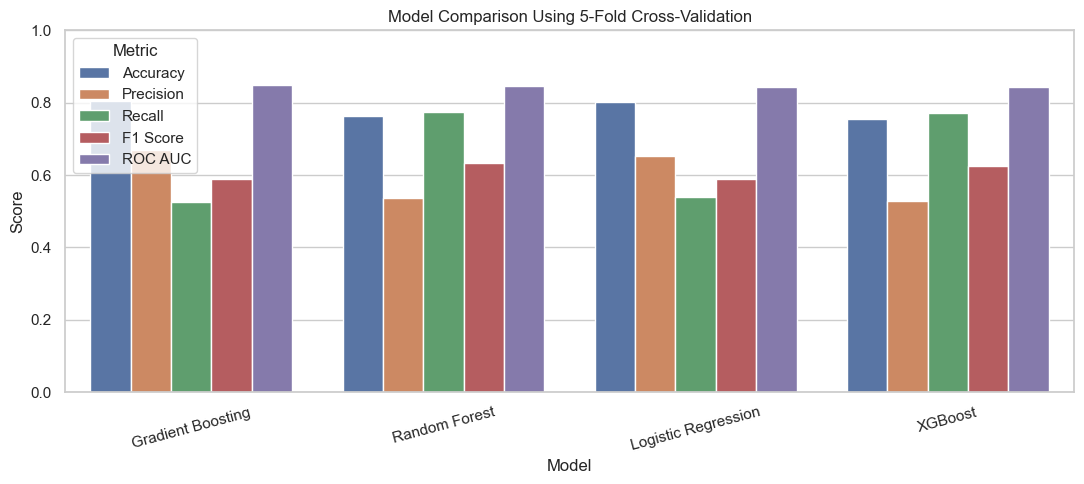

In [13]:
cv_melted = cv_results_display.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=cv_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Comparison Using 5-Fold Cross-Validation")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "07_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on ROC AUC:", best_model_name)

Best model based on ROC AUC: Gradient Boosting


### Model Selection Note

Gradient Boosting achieved the highest cross-validation ROC AUC in benchmarking. However, XGBoost was selected as the final model because it provides strong performance on tabular data, supports class imbalance handling through `scale_pos_weight`, and integrates well with SHAP explainability for business interpretation.

In [15]:
final_model = models["XGBoost"]

final_model.fit(X_train, y_train)

y_pred_default = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

In [16]:
default_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_default),
    "Precision": precision_score(y_test, y_pred_default),
    "Recall": recall_score(y_test, y_pred_default),
    "F1 Score": f1_score(y_test, y_pred_default),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

default_metrics_df = pd.DataFrame([default_metrics]).round(4)

default_metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.7456,0.514,0.7861,0.6216,0.8329


In [17]:
print(classification_report(y_test, y_pred_default, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.75      0.76      1407



## Business-Cost-Based Threshold Tuning

A default classification threshold of 0.50 may not be optimal for churn prediction.

In this project, the threshold is tuned using business cost assumptions:

- False Negative: A real churner is missed by the model.
- False Positive: A non-churner is incorrectly targeted with a retention offer.

Assumptions:

- Cost of missing a churner = ₹780
- Cost of giving unnecessary retention offer = ₹20

The goal is to find the threshold that minimizes total business cost.

In [27]:
false_negative_cost = 780
false_positive_cost = 100

thresholds = np.arange(0.05, 0.95, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    total_cost = (fn * false_negative_cost) + (fp * false_positive_cost)
    
    threshold_results.append({
        "Threshold": threshold,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Total Cost": total_cost,
        "Recall": recall_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.head()

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Total Cost,Recall,Precision,F1 Score
0,0.05,285,748,5,369,78700,0.986631,0.330349,0.494970
1,0.06,305,728,5,369,76700,0.986631,0.336372,0.501700
2,0.07,330,703,6,368,74980,0.983957,0.343604,0.509343
3,0.08,352,681,7,367,73560,0.981283,0.350191,0.516174
4,0.09,366,667,7,367,72160,0.981283,0.354932,0.521307


In [28]:
best_threshold_row = threshold_df.loc[threshold_df["Total Cost"].idxmin()]
best_threshold = best_threshold_row["Threshold"]

best_threshold_row

Threshold              0.230000
True Negatives       537.000000
False Positives      496.000000
False Negatives       26.000000
True Positives       348.000000
Total Cost         69880.000000
Recall                 0.930481
Precision              0.412322
F1 Score               0.571429
Name: 18, dtype: float64

In [29]:
y_pred_best = (y_proba >= best_threshold).astype(int)

best_threshold_metrics = {
    "Best Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1 Score": f1_score(y_test, y_pred_best),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

best_threshold_metrics_df = pd.DataFrame([best_threshold_metrics]).round(4)

best_threshold_metrics_df

,Best Threshold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.23,0.629,0.4123,0.9305,0.5714,0.8329


In [30]:
default_comparison = default_metrics_df.copy()
default_comparison["Threshold"] = 0.50
default_comparison["Strategy"] = "Default Threshold"

business_comparison = best_threshold_metrics_df.copy()
business_comparison["Threshold"] = business_comparison["Best Threshold"]
business_comparison["Strategy"] = "Business-Cost Threshold"
business_comparison = business_comparison.drop(columns=["Best Threshold"])

comparison_df = pd.concat(
    [default_comparison, business_comparison],
    ignore_index=True
)

comparison_df = comparison_df[
    ["Strategy", "Threshold", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
]

comparison_df

,Strategy,Threshold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Default Threshold,0.50,0.7456,0.5140,0.7861,0.6216,0.8329
1,Business-Cost Threshold,0.23,0.6290,0.4123,0.9305,0.5714,0.8329


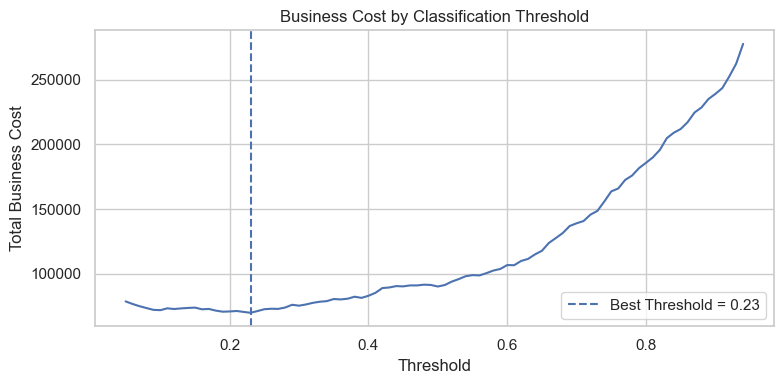

In [32]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=threshold_df,
    x="Threshold",
    y="Total Cost"
)

plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")

plt.title("Business Cost by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.legend()

plt.tight_layout()
plt.savefig(IMAGE_DIR / "08_threshold_cost_curve.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 600x500 with 0 Axes>

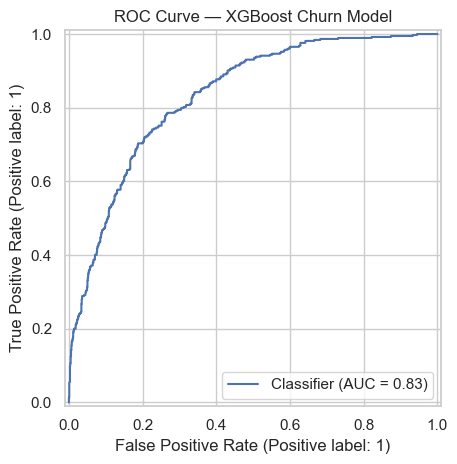

In [33]:
plt.figure(figsize=(6, 5))

RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("ROC Curve — XGBoost Churn Model")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "09_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 600x500 with 0 Axes>

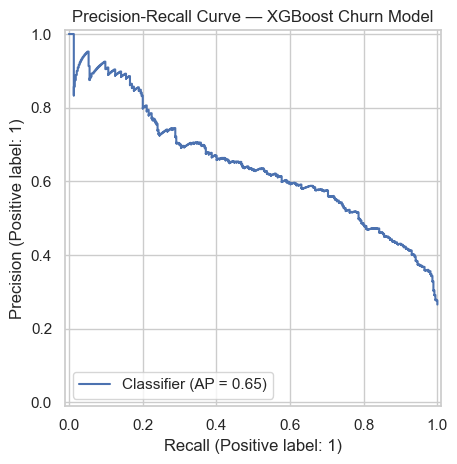

In [35]:
plt.figure(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_proba)

plt.title("Precision-Recall Curve — XGBoost Churn Model")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "10_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
)

cm_df

,Predicted No Churn,Predicted Churn
Actual No Churn,537,496
Actual Churn,26,348


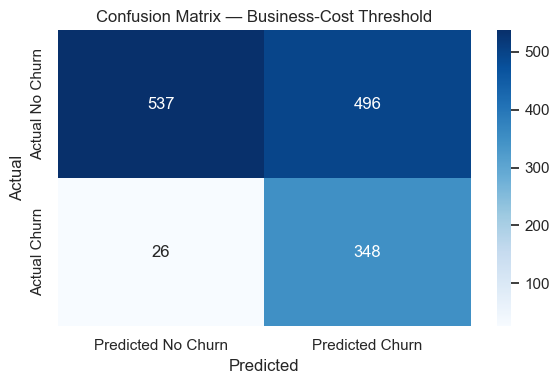

In [37]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix — Business-Cost Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "11_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

cost_summary = pd.DataFrame({
    "Outcome": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Count": [tn, fp, fn, tp],
    "Cost per Case": [0, false_positive_cost, false_negative_cost, 0],
    "Total Cost": [
        0,
        fp * false_positive_cost,
        fn * false_negative_cost,
        0
    ]
})

cost_summary

,Outcome,Count,Cost per Case,Total Cost
0,True Negative,537,0,0
1,False Positive,496,100,49600
2,False Negative,26,780,20280
3,True Positive,348,0,0


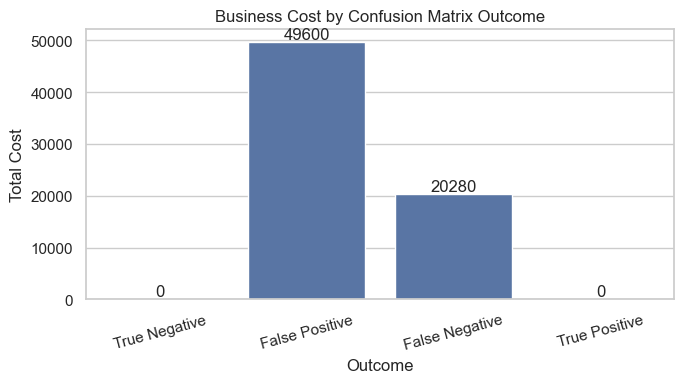

In [39]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=cost_summary,
    x="Outcome",
    y="Total Cost"
)

plt.title("Business Cost by Confusion Matrix Outcome")
plt.xlabel("Outcome")
plt.ylabel("Total Cost")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "12_confusion_matrix_cost.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Use a sample for faster SHAP calculation
X_test_sample = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


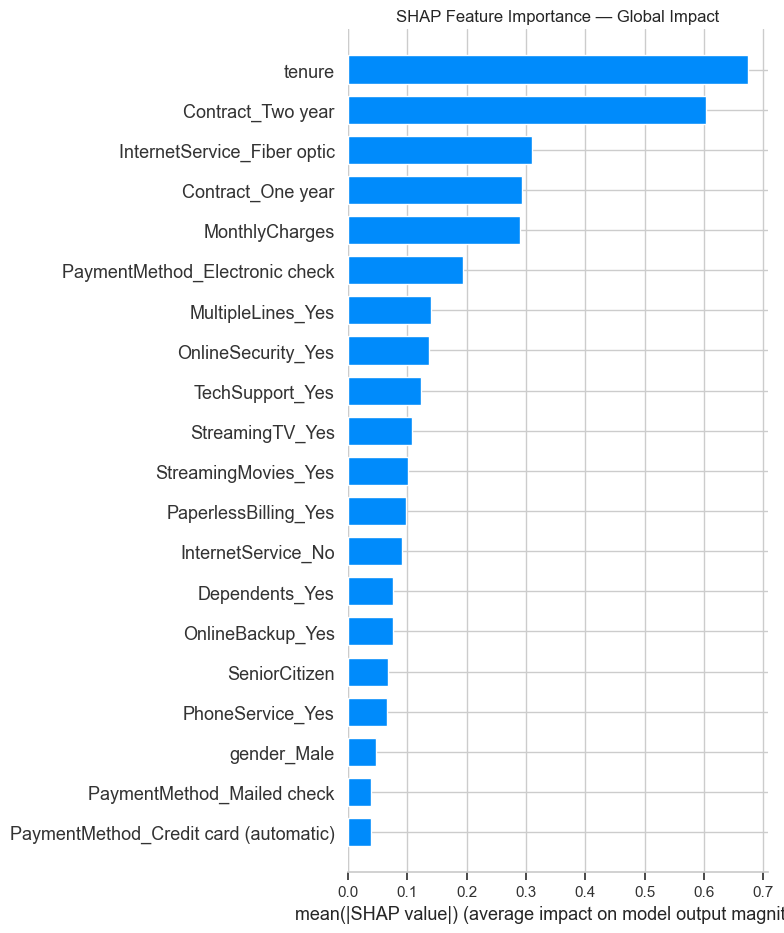

In [41]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — Global Impact")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "13_shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

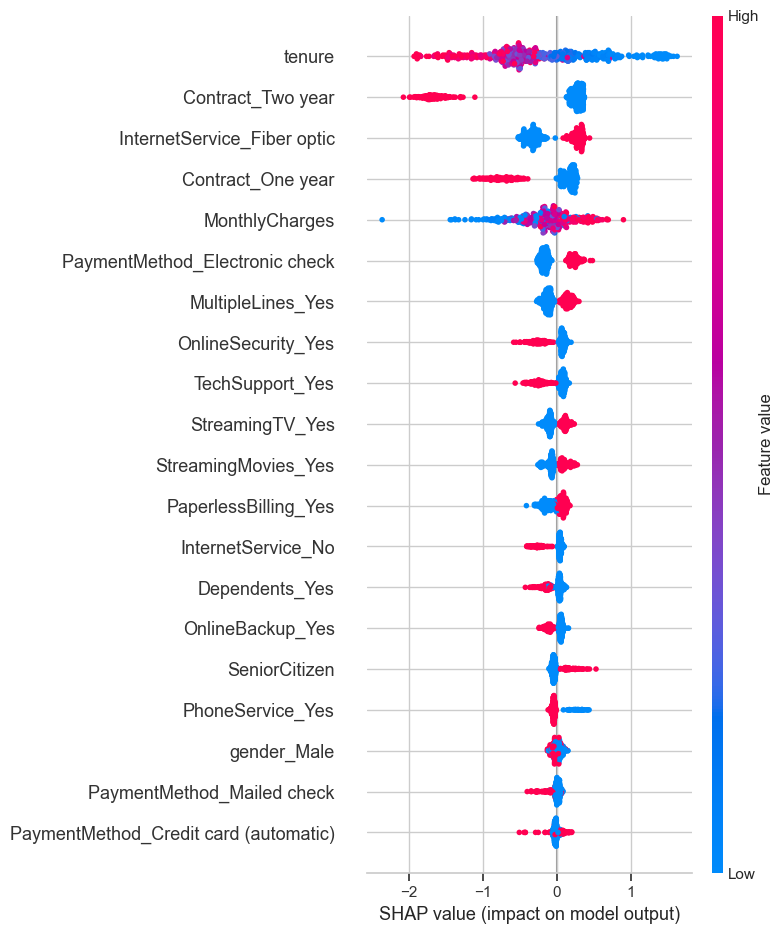

In [42]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "14_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

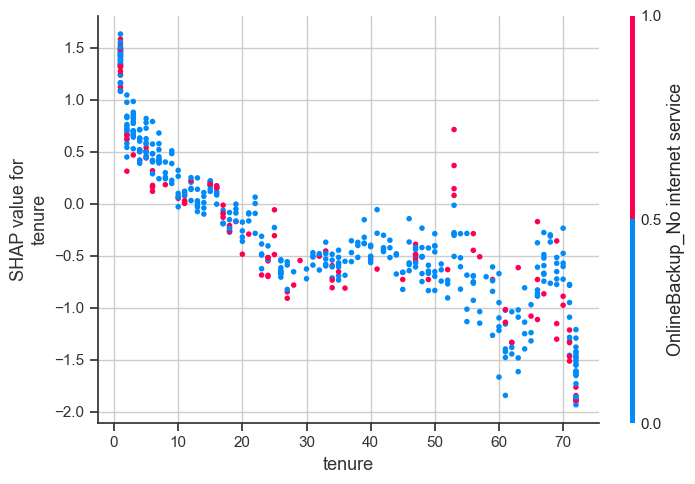

In [43]:
shap.dependence_plot(
    "tenure",
    shap_values,
    X_test_sample,
    show=False
)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "15_shap_dependence_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

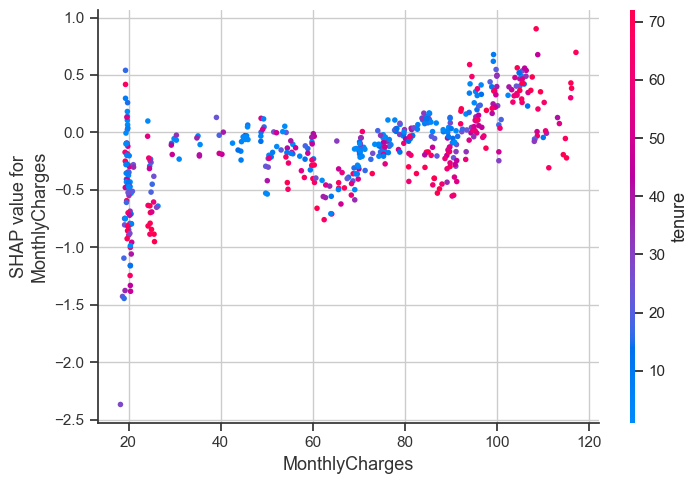

In [44]:
shap.dependence_plot(
    "MonthlyCharges",
    shap_values,
    X_test_sample,
    show=False
)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "16_shap_dependence_monthly_charges.png", dpi=300, bbox_inches="tight")
plt.show()

## SHAP Explainability Insights

SHAP analysis shows which customer attributes most strongly influence churn prediction.

Key business interpretations:

- Shorter tenure increases churn risk.
- Month-to-month contracts are associated with higher churn probability.
- Long-term contracts reduce churn probability.
- Higher monthly charges can increase churn risk for some customer groups.
- Service-related features such as online security and tech support help explain churn behavior.

These insights help convert the model from a black-box predictor into a business decision-support tool.

In [45]:
all_customer_proba = final_model.predict_proba(X_encoded)[:, 1]

risk_output = df.copy()
risk_output["ChurnProbability"] = all_customer_proba

risk_output[["customerID", "ChurnProbability"]].head()

,customerID,ChurnProbability
0,7590-VHVEG,0.870222
1,5575-GNVDE,0.063777
2,3668-QPYBK,0.637042
3,7795-CFOCW,0.090895
4,9237-HQITU,0.823196


In [46]:
def assign_risk_tier(probability):
    if probability >= 0.75:
        return "Critical"
    elif probability >= 0.50:
        return "High"
    elif probability >= 0.25:
        return "Medium"
    else:
        return "Low"

risk_output["RiskTier"] = risk_output["ChurnProbability"].apply(assign_risk_tier)

risk_output[["customerID", "ChurnProbability", "RiskTier"]].head()

,customerID,ChurnProbability,RiskTier
0,7590-VHVEG,0.870222,Critical
1,5575-GNVDE,0.063777,Low
2,3668-QPYBK,0.637042,High
3,7795-CFOCW,0.090895,Low
4,9237-HQITU,0.823196,Critical


In [47]:
def recommend_action(row):
    if row["RiskTier"] == "Critical":
        return "Immediate retention call + personalized discount"
    elif row["RiskTier"] == "High":
        return "Targeted retention offer"
    elif row["RiskTier"] == "Medium":
        return "Monitor and send engagement campaign"
    else:
        return "No immediate action"

risk_output["RecommendedAction"] = risk_output.apply(recommend_action, axis=1)

risk_output[["customerID", "RiskTier", "RecommendedAction"]].head()

,customerID,RiskTier,RecommendedAction
0,7590-VHVEG,Critical,Immediate retention call + personalized discount
1,5575-GNVDE,Low,No immediate action
2,3668-QPYBK,High,Targeted retention offer
3,7795-CFOCW,Low,No immediate action
4,9237-HQITU,Critical,Immediate retention call + personalized discount


In [48]:
dashboard_columns = [
    "customerID",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "TenureBucket",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn",
    "ChurnProbability",
    "RiskTier",
    "RecommendedAction"
]

customer_risk_scores = risk_output[dashboard_columns].copy()

customer_risk_scores.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,TenureBucket,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnProbability,RiskTier,RecommendedAction
0,7590-VHVEG,Female,0,Yes,No,1,0-12 months,Month-to-month,DSL,Electronic check,29.85,29.85,No,0.870222,Critical,Immediate retention call + personalized discount
1,5575-GNVDE,Male,0,No,No,34,25-48 months,One year,DSL,Mailed check,56.95,1889.50,No,0.063777,Low,No immediate action
2,3668-QPYBK,Male,0,No,No,2,0-12 months,Month-to-month,DSL,Mailed check,53.85,108.15,Yes,0.637042,High,Targeted retention offer
3,7795-CFOCW,Male,0,No,No,45,25-48 months,One year,DSL,Bank transfer (automatic),42.30,1840.75,No,0.090895,Low,No immediate action
4,9237-HQITU,Female,0,No,No,2,0-12 months,Month-to-month,Fiber optic,Electronic check,70.70,151.65,Yes,0.823196,Critical,Immediate retention call + personalized discount


In [49]:
risk_scores_path = PROCESSED_DIR / "customer_risk_scores.csv"

customer_risk_scores.to_csv(risk_scores_path, index=False)

print(f"Customer risk scores exported to: {risk_scores_path}")
print("Rows exported:", customer_risk_scores.shape[0])
print("Columns exported:", customer_risk_scores.shape[1])

Customer risk scores exported to: c:\Users\HP\Desktop\customer-churn-retention-analytics\data\processed\customer_risk_scores.csv
Rows exported: 7032
Columns exported: 16


In [50]:
model_path = MODEL_DIR / "xgboost_churn_model.pkl"

joblib.dump(final_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: c:\Users\HP\Desktop\customer-churn-retention-analytics\models\xgboost_churn_model.pkl


In [51]:
total_customers = customer_risk_scores.shape[0]

critical_customers = (customer_risk_scores["RiskTier"] == "Critical").sum()
high_customers = (customer_risk_scores["RiskTier"] == "High").sum()

avg_monthly_charge = customer_risk_scores["MonthlyCharges"].mean()

high_risk_revenue = customer_risk_scores[
    customer_risk_scores["RiskTier"].isin(["Critical", "High"])
]["MonthlyCharges"].sum()

estimated_annual_revenue_at_risk = high_risk_revenue * 12

business_impact = pd.DataFrame({
    "Metric": [
        "Total Customers Scored",
        "Critical Risk Customers",
        "High Risk Customers",
        "Monthly Revenue at Risk",
        "Estimated Annual Revenue at Risk"
    ],
    "Value": [
        total_customers,
        critical_customers,
        high_customers,
        round(high_risk_revenue, 2),
        round(estimated_annual_revenue_at_risk, 2)
    ]
})

business_impact

,Metric,Value
0,Total Customers Scored,7032.00
1,Critical Risk Customers,1383.00
2,High Risk Customers,1409.00
3,Monthly Revenue at Risk,209006.95
4,Estimated Annual Revenue at Risk,2508083.40


## Final ML Summary

The final XGBoost model predicts customer churn probability and assigns each customer to a risk tier.

Key outputs generated:

- Trained XGBoost churn model
- Customer-level churn probability
- Risk tier classification
- Recommended retention action
- CSV export for Power BI dashboard
- SHAP explainability charts for business interpretation

The model achieved strong churn separation using ROC AUC and was further tuned using business-cost assumptions to prioritize retention decisions.